In [1]:
sentences = [
    # Cricket
    "The batsman smashed a huge six towards the mid-wicket boundary.",
    "The spinner tricked the opener with a googly and got him out.",
    "India secured the victory by losing only three wickets.",
    "The bowler bowled an accurate yorker on the last delivery.",

    # Cooking
    "Pour two spoons of oil into a preheated pan.",
    "Keep kneading the dough until it turns soft and smooth.",
    "Let the curry cook on a low flame for about twenty minutes.",

    # Cybersecurity
    "The attacker used a phishing email to steal login details.",
    "You should always turn on two-factor authentication for better security.",
    "Firewalls act as a barrier to prevent unauthorized access to networks."
]


labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cyber 1",   "Cyber 2",   "Cyber 3"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}. {s}")

Total sentences: 10
1. The batsman smashed a huge six towards the mid-wicket boundary.
2. The spinner tricked the opener with a googly and got him out.
3. India secured the victory by losing only three wickets.
4. The bowler bowled an accurate yorker on the last delivery.
5. Pour two spoons of oil into a preheated pan.
6. Keep kneading the dough until it turns soft and smooth.
7. Let the curry cook on a low flame for about twenty minutes.
8. The attacker used a phishing email to steal login details.
9. You should always turn on two-factor authentication for better security.
10. Firewalls act as a barrier to prevent unauthorized access to networks.


In [6]:
# Cell 2 — Install required libraries
!pip install sentence-transformers scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 24.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 21.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 31.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m8/9 [seaborn]ib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# Cell 3 — Load model and generate embeddings
from sentence_transformers import SentenceTransformer
import numpy as np

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all 10 sentences
embeddings = model.encode(sentences)

print(f"Model loaded successfully!")
print(f"Embeddings shape: {embeddings.shape}")
print(f"Each sentence = {embeddings.shape[1]} numbers")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14535.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!
Embeddings shape: (10, 384)
Each sentence = 384 numbers


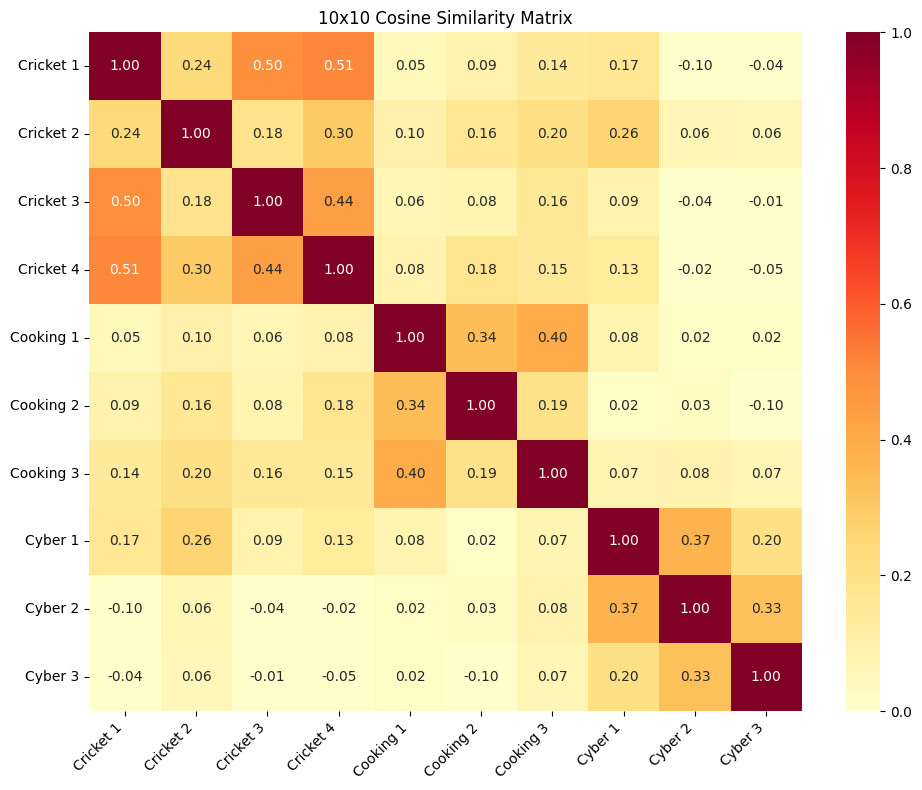

Heatmap saved!


In [7]:
# Cell 4 — Cosine similarity matrix + heatmap
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Compute 10x10 similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)
plt.title("10x10 Cosine Similarity Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved!")

In [8]:
# Cell 5 — Find top 2 most similar sentences to a query
from sklearn.metrics.pairwise import cosine_similarity

# Query sentence
query = "The bowler took three wickets in one over"

# Encode the query
query_embedding = model.encode([query])

# Compute similarity with all sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_2_indices = similarities.argsort()[-2:][::-1]

# Print results
print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:\n")
for rank, idx in enumerate(top_2_indices, 1):
    print(f"{rank}. {sentences[idx]}")
    print(f"   Similarity Score: {similarities[idx]:.4f}\n")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:

1. India secured the victory by losing only three wickets.
   Similarity Score: 0.6698

2. The bowler bowled an accurate yorker on the last delivery.
   Similarity Score: 0.6497



In [10]:
# Cell 6 — Summary
print("=" * 55)
print("EMBEDDINGS DEMO — SUMMARY")
print("=" * 55)
print(f"\nModel Used    : all-MiniLM-L6-v2")
print(f"Total Sentences: {len(sentences)}")
print(f"Topics         : Cricket, Cooking, Cybersecurity")
print(f"Embedding Size : {embeddings.shape[1]} dimensions")
print(f"\nQuery Sentence:")
print(f"  '{query}'")
print(f"\nTop 2 Similar Sentences:")
for rank, idx in enumerate(top_2_indices, 1):
    print(f"  Rank {rank}: {sentences[idx]}")
    print(f"          Similarity = {similarities[idx]:.4f}")
print("\nConclusion:")
print("  Same-topic sentences show high similarity (0.5-1.0)")
print("  Cross-topic sentences show low similarity (0.0-0.2)")
print("=" * 55)

EMBEDDINGS DEMO — SUMMARY

Model Used    : all-MiniLM-L6-v2
Total Sentences: 10
Topics         : Cricket, Cooking, Cybersecurity
Embedding Size : 384 dimensions

Query Sentence:
  'The bowler took three wickets in one over'

Top 2 Similar Sentences:
  Rank 1: India secured the victory by losing only three wickets.
          Similarity = 0.6698
  Rank 2: The bowler bowled an accurate yorker on the last delivery.
          Similarity = 0.6497

Conclusion:
  Same-topic sentences show high similarity (0.5-1.0)
  Cross-topic sentences show low similarity (0.0-0.2)
